# 05 — Sentinel-1 + Sentinel-2 Data Fusion for LULC Classification

## Optical + SAR Feature-level Fusion
**Google Earth Engine Python API + Google Colab**

**พื้นที่ศึกษา:** อำเภอเมืองพิษณุโลก จังหวัดพิษณุโลก  
**ข้อมูล:** Sentinel-2 Surface Reflectance + Sentinel-1 GRD, ปี 2021  
**ระดับ:** ปริญญาตรีปี 4 / ปริญญาโทด้านสิ่งแวดล้อม

Notebook นี้เป็น **Capstone** ของชุดการเรียน

เราจะเปรียบเทียบ 4 models

```text
Model A — Sentinel-2 January
Model B — Sentinel-1 January
Model C — Sentinel-2 + Sentinel-1 January
Model D — Sentinel-2 + Sentinel-1 Annual
```

คำถามหลัก:

> **Optical และ SAR ให้ข้อมูลที่เสริมกันหรือไม่?**

และ

> **การเพิ่ม temporal SAR information ช่วย class ใดมากที่สุด?**

## Learning objectives

เมื่อจบ Notebook นี้ ผู้เรียนควรสามารถ

1. แยกความแตกต่างระหว่าง **mapping area** และ **reference-data domain**
2. ตรวจว่าจุด training/validation อยู่ภายในหรือภายนอกพื้นที่ map
3. เตรียม Sentinel-2 spectral features และ Sentinel-1 temporal features โดยไม่ clip เร็วเกินไป
4. อธิบาย **feature-level data fusion**
5. สร้างและเปรียบเทียบ 4 Random Forest models
6. ใช้ validation set เดียวกันอย่างเป็นธรรม
7. อ่าน OA, PA, UA, F1 และ $\Delta F1$
8. อธิบาย sensor complementarity
9. รวม Random Forest importance ตาม sensor source
10. สร้าง disagreement map และอธิบายว่า disagreement ไม่เท่ากับ error
11. export final fusion map เป็น GeoTIFF สำหรับ QGIS

# Part 1 — What did Notebooks 01–04 teach us?

```text
Notebook 01
S2 spectral classification
        ↓
Notebook 02
Training geometry / spatial support
        ↓
Notebook 03
SAR physics + temporal backscatter
        ↓
Notebook 04
January SAR vs Annual SAR
        ↓
Notebook 05
S1 + S2 fusion
```

ผลจาก Notebook 04 แสดงว่า full-year SAR ช่วยบาง class มาก โดยเฉพาะ class ที่มี temporal variability

แต่ยังพบปัญหาสำคัญ:

```text
Reference samples
        ↓
บางจุดอยู่นอก mapping district
        ↓
predictor ถูก clip เร็วเกินไป
        ↓
sampleRegions() ตัดบางจุดออก
```

ดังนั้น Notebook 05 จะ **แก้ spatial domain ก่อนทำ fusion**

## Research questions

### Q1 — Sensor comparison

$$
S2\quad vs\quad S1
$$

sensor ใดเหมาะกับ class ใด?

### Q2 — Same-period fusion

$$
S2_{Jan}+S1_{Jan}
$$

ช่วยมากกว่าใช้ S2 เพียงอย่างเดียวหรือไม่?

### Q3 — Spectral + temporal fusion

$$
S2_{Jan}+S1_{Jan-Dec}
$$

ช่วย class ที่มี temporal behaviour เช่น Agriculture หรือไม่?

### Q4 — Scientific interpretation

ถ้า model มี accuracy สูงขึ้น

> improvement มาจาก information ที่เสริมกันจริง หรือจาก sampling / domain ที่เปลี่ยน?

In [1]:
# Import libraries

import ee
import folium
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from IPython.display import display

print("Earth Engine API version:", ee.__version__)
print("Folium version:", folium.__version__)

Earth Engine API version: 1.7.39
Folium version: 0.20.0


In [2]:
# Authenticate and initialize Google Earth Engine

PROJECT = "teach-gee-github-lulc"

ee.Authenticate()
ee.Initialize(project=PROJECT)

print("Earth Engine initialized successfully.")

Earth Engine initialized successfully.


*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


In [3]:
# Common mapping helpers and class definitions

def add_ee_layer(map_object, ee_image, vis_params, name,
                 shown=True, opacity=1.0):
    map_id = ee.Image(ee_image).getMapId(vis_params)

    folium.raster_layers.TileLayer(
        tiles=map_id["tile_fetcher"].url_format,
        attr="Google Earth Engine",
        name=name,
        overlay=True,
        control=True,
        show=shown,
        opacity=opacity,
    ).add_to(map_object)


def add_esri_imagery(map_object, shown=False):
    folium.TileLayer(
        tiles=(
            "https://server.arcgisonline.com/ArcGIS/rest/services/"
            "World_Imagery/MapServer/tile/{z}/{y}/{x}"
        ),
        attr="Esri, Maxar, Earthstar Geographics, and the GIS User Community",
        name="Esri World Imagery",
        overlay=False,
        control=True,
        show=shown,
    ).add_to(map_object)


CLASS_COLORS = {
    0: "#d73027",
    1: "#2166ac",
    2: "#1a9850",
    3: "#fee08b",
    4: "#a6611a",
}

CLASS_NAMES = {
    0: "Urban",
    1: "Water",
    2: "Forest",
    3: "Agriculture",
    4: "Bare soil",
}

CLASS_ORDER = [0, 1, 2, 3, 4]

CLASS_PALETTE = [
    CLASS_COLORS[i].replace("#", "")
    for i in CLASS_ORDER
]

SEED = 42

# Part 2 — Load the same reference dataset

เรายังคงใช้

```text
101 reference points
71 training locations
30 validation locations
```

และ **ห้าม random split ใหม่**

เพราะเป้าหมายคือ controlled comparison

In [4]:
# Load shared reference CSV

LOCAL_CSV = Path("/content/phitsanulok_lulc_points.csv")

GITHUB_CSV = (
    "https://raw.githubusercontent.com/"
    "nattaponm/Teach-GEE-LULC/main/"
    "data/phitsanulok_lulc_points.csv"
)

if LOCAL_CSV.exists():
    samples_df = pd.read_csv(LOCAL_CSV)
    print("Loaded:", LOCAL_CSV)
else:
    try:
        samples_df = pd.read_csv(GITHUB_CSV)
        print("Loaded from GitHub:", GITHUB_CSV)
    except Exception:
        print(
            "CSV was not found on GitHub yet.\n"
            "Upload phitsanulok_lulc_points.csv to Colab."
        )
        from google.colab import files

        uploaded = files.upload()
        filename = next(iter(uploaded))
        samples_df = pd.read_csv(filename)

samples_df["class_id"] = samples_df["class_id"].astype(int)

display(samples_df.head())

Loaded from GitHub: https://raw.githubusercontent.com/nattaponm/Teach-GEE-LULC/main/data/phitsanulok_lulc_points.csv


,sample_id,longitude,latitude,class_id,class_name,split
0,UR001,100.269879,16.817238,0,Urban,train
1,UR002,100.285468,16.817505,0,Urban,validation
2,UR003,100.256249,16.804334,0,Urban,validation
3,UR004,100.279540,16.782361,0,Urban,train
4,UR005,100.197563,16.753218,0,Urban,validation


In [5]:
# Verify fixed split

if "split" not in samples_df.columns:
    raise ValueError(
        "The CSV must contain the fixed split created in Notebook 01."
    )

split_table = pd.crosstab(
    samples_df["class_name"],
    samples_df["split"],
    margins=True,
)

display(split_table)

print("Training:",
      (samples_df["split"] == "train").sum())

print("Validation:",
      (samples_df["split"] == "validation").sum())

split,train,validation,All
class_name,,,
Agriculture,14,6,20
Bare soil,15,6,21
Forest,14,6,20
Urban,14,6,20
Water,14,6,20
All,71,30,101


Training: 71
Validation: 30


In [6]:
# Convert reference points to Earth Engine

def dataframe_to_ee_points(df):
    features = []

    for row in df.itertuples(index=False):
        geom = ee.Geometry.Point(
            [float(row.longitude), float(row.latitude)]
        )

        properties = {
            "sample_id": str(row.sample_id),
            "longitude": float(row.longitude),
            "latitude": float(row.latitude),
            "class_id": int(row.class_id),
            "class_name": str(row.class_name),
            "split": str(row.split),
        }

        features.append(
            ee.Feature(geom, properties)
        )

    return ee.FeatureCollection(features)


all_points = dataframe_to_ee_points(samples_df)

training_points = all_points.filter(
    ee.Filter.eq("split", "train")
)

validation_points = all_points.filter(
    ee.Filter.eq("split", "validation")
)

print("All points:", all_points.size().getInfo())
print("Training:", training_points.size().getInfo())
print("Validation:", validation_points.size().getInfo())

All points: 101
Training: 71
Validation: 30


# Part 3 — Mapping area vs Reference-data domain

นี่เป็น concept ใหม่ที่สำคัญ

## Mapping area

พื้นที่ที่เราต้องการสร้าง final map

```text
Mueang Phitsanulok District
```

## Reference-data domain

พื้นที่ที่ต้องครอบคลุม training และ validation samples ทั้งหมด

สอง geometry นี้ **ไม่จำเป็นต้องเหมือนกัน**

ผิด:

```text
clip predictor to map area
        ↓
sample reference points
```

เพราะ reference points นอก mapping area จะถูก mask

ถูก:

```text
prepare predictors over reference domain
        ↓
sample ALL reference points
        ↓
train / validate
        ↓
classify
        ↓
clip FINAL map to mapping area
```

In [7]:
# Define mapping area

roi = ee.Geometry.Point([100.26575, 16.82277])

gaul2 = (
    ee.FeatureCollection("FAO/GAUL/2025/level2")
    .filter(ee.Filter.eq("GAUL0_NAME", "Thailand"))
)

district_fc = gaul2.filterBounds(roi)
map_area = district_fc.geometry()

print("Mapping district candidate(s):")
display(district_fc.aggregate_array("DISP_EN").getInfo())

Mapping district candidate(s):


['Mueang Phitsanulok, Phitsanulok, Thailand']

In [10]:
# Flag whether each reference point is inside the mapping area

def flag_inside_map(feature):
    feature = ee.Feature(feature)

    # ee.Geometry.contains() returns an ee.Boolean.
    inside = map_area.contains(
        feature.geometry(),
        maxError=1,
    )

    # Convert Boolean -> 1 / 0
    inside_flag = ee.Number(
        ee.Algorithms.If(
            inside,
            1,
            0,
        )
    ).int()

    return feature.set(
        "inside_map_area",
        inside_flag,
    )


flagged_points = all_points.map(
    flag_inside_map
)

flagged_info = flagged_points.getInfo()["features"]

domain_records = [
    feature["properties"]
    for feature in flagged_info
]

domain_df = pd.DataFrame(domain_records)

domain_table = pd.crosstab(
    domain_df["class_name"],
    domain_df["inside_map_area"],
)

domain_table = domain_table.rename(
    columns={
        0: "Outside_map_area",
        1: "Inside_map_area",
    }
)

display(domain_table)

print(
    "Total outside mapping area:",
    int(
        (domain_df["inside_map_area"] == 0).sum()
    ),
)

inside_map_area,Outside_map_area,Inside_map_area
class_name,,
Agriculture,0,20
Bare soil,0,21
Forest,10,10
Urban,0,20
Water,0,20


Total outside mapping area: 10


## Interpretation

ถ้ามี reference points อยู่นอก district:

> นั่นไม่ได้หมายความว่าจุดเหล่านั้น “ผิด”

อาจเป็นเพราะ reference dataset ถูกออกแบบให้ครอบคลุม spectral / radar variability กว้างกว่าพื้นที่ final map

แต่ predictor image ต้องครอบคลุมจุดเหล่านั้นก่อน sample

นี่คือเหตุผลที่บาง Forest samples ใน Notebook ก่อนหน้าหายเมื่อ predictor ถูก clip ด้วย district เร็วเกินไป

In [11]:
# Build a processing/reference domain that covers all reference points
# Add a small buffer so image filtering is not exactly on the sample bounds.

reference_bounds = (
    all_points
    .geometry()
    .bounds(maxError=1)
)

processing_domain = (
    reference_bounds
    .buffer(5000)
    .bounds(maxError=1)
)

print("Processing domain created to cover all reference points.")

Processing domain created to cover all reference points.


In [12]:
# Folium — map area vs reference-data domain

Map = folium.Map(
    location=[16.83, 100.30],
    zoom_start=9,
    tiles=None,
)

add_esri_imagery(Map, shown=True)

map_area_style = district_fc.style(
    color="00FFFF",
    fillColor="00000000",
    width=3,
)

reference_bounds_fc = ee.FeatureCollection([
    ee.Feature(reference_bounds)
])

reference_style = reference_bounds_fc.style(
    color="FFFF00",
    fillColor="00000000",
    width=2,
)

add_ee_layer(
    Map,
    map_area_style,
    {},
    "Final mapping area",
    shown=True,
)

add_ee_layer(
    Map,
    reference_style,
    {},
    "Reference-data extent",
    shown=True,
)

# Add reference points as Folium markers.
point_group = folium.FeatureGroup(
    name="Reference points",
    show=True,
)

for row in samples_df.itertuples(index=False):
    folium.CircleMarker(
        location=[row.latitude, row.longitude],
        radius=4,
        color=CLASS_COLORS[int(row.class_id)],
        fill=True,
        fill_color=CLASS_COLORS[int(row.class_id)],
        fill_opacity=0.8,
        tooltip=f"{row.sample_id} | {row.class_name}",
    ).add_to(point_group)

point_group.add_to(Map)

folium.LayerControl(
    collapsed=False
).add_to(Map)

Map

# Part 4 — What is Feature-level Data Fusion?

Data fusion ในบทนี้ **ไม่ใช่**

- การ blend สีของภาพ
- การ average pixel
- การนำ RGB มาซ้อนกัน

เราจะรวม predictor variables

สำหรับ Sentinel-2:

$$
\mathbf{x}_{S2}
=
[
B2,B3,B4,B8,B11,B12,
NDVI,NDWI,NDBI
]
$$

สำหรับ Sentinel-1 January:

$$
\mathbf{x}_{S1,Jan}
=
[
VV_{Jan},VH_{Jan}
]
$$

ดังนั้น same-period fusion คือ

$$
\mathbf{x}_{Fusion,Jan}
=
[
\mathbf{x}_{S2},
\mathbf{x}_{S1,Jan}
]
$$

เรียกว่า **feature-level fusion**

# Part 5 — Four models

เราจะเปรียบเทียบ

| Model | Information | Predictors |
|---|---|---:|
| A | S2 January | 9 |
| B | S1 January | 2 |
| C | S2 + S1 January | 11 |
| D | S2 + Annual S1 | 33 |

### Model A vs B

เปรียบเทียบ optical vs SAR

### Model A vs C

ทดสอบ **same-period sensor complementarity**

### Model C vs D

ทดสอบประโยชน์ของ **temporal SAR information**

ทุก model ใช้

```text
same training geometry
same RF settings
same validation locations
```

# Part 6 — Prepare Sentinel-2 predictors

ใช้ช่วงเวลาเดียวกับ Notebook 01–02

```text
2021-01-01 → 2021-02-01
```

แต่คราวนี้ **ยังไม่ clip ด้วย district**

เพราะ predictor ต้องครอบคลุม reference-data domain ก่อน sampling

In [13]:
# Sentinel-2 January Surface Reflectance

S2_START = "2021-01-01"
S2_END = "2021-02-01"

S2_SPECTRAL_BANDS = [
    "B2", "B3", "B4",
    "B8", "B11", "B12",
]

s2_raw = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(processing_domain)
    .filterDate(S2_START, S2_END)
    .filter(
        ee.Filter.lt(
            "CLOUDY_PIXEL_PERCENTAGE",
            50,
        )
    )
)

print("Sentinel-2 scenes:",
      s2_raw.size().getInfo())

Sentinel-2 scenes: 14


In [14]:
# Sentinel-2 SCL masking and monthly median

def mask_s2_scl(image):
    scl = image.select("SCL")

    mask = (
        scl.neq(0)
        .And(scl.neq(1))
        .And(scl.neq(3))
        .And(scl.neq(8))
        .And(scl.neq(9))
        .And(scl.neq(10))
        .And(scl.neq(11))
    )

    return (
        image
        .updateMask(mask)
        .select(S2_SPECTRAL_BANDS)
        .multiply(0.0001)
        .copyProperties(
            image,
            ["system:time_start"],
        )
    )


s2 = (
    s2_raw
    .map(mask_s2_scl)
    .median()
)

In [15]:
# Sentinel-2 indices and 9-band feature stack

s2_ndvi = (
    s2.normalizedDifference(
        ["B8", "B4"]
    )
    .rename("S2_NDVI")
)

s2_ndwi = (
    s2.normalizedDifference(
        ["B3", "B8"]
    )
    .rename("S2_NDWI")
)

s2_ndbi = (
    s2.normalizedDifference(
        ["B11", "B8"]
    )
    .rename("S2_NDBI")
)

s2_spectral = s2.select(
    S2_SPECTRAL_BANDS,
    [
        "S2_B2",
        "S2_B3",
        "S2_B4",
        "S2_B8",
        "S2_B11",
        "S2_B12",
    ],
)

s2_predictors = (
    s2_spectral
    .addBands([
        s2_ndvi,
        s2_ndwi,
        s2_ndbi,
    ])
)

S2_BANDS = s2_predictors.bandNames().getInfo()

print("S2 predictors:", len(S2_BANDS))
display(S2_BANDS)

S2 predictors: 9


['S2_B2',
 'S2_B3',
 'S2_B4',
 'S2_B8',
 'S2_B11',
 'S2_B12',
 'S2_NDVI',
 'S2_NDWI',
 'S2_NDBI']

# Part 7 — Prepare Sentinel-1 predictors

ใช้ workflow ที่ปรับปรุงจาก Notebook 04

```text
S1 GRD
  ↓
IW VV/VH
  ↓
homogeneous orbit
  ↓
same-date mosaic
  ↓
monthly median
  ↓
January 2-band stack
  ↓
Annual 24-band stack
```

และยัง **ไม่ clip ด้วย final mapping district**

In [16]:
# Sentinel-1 base collection

YEAR = 2021

s1_base = (
    ee.ImageCollection("COPERNICUS/S1_GRD")
    .filterBounds(processing_domain)
    .filterDate(
        f"{YEAR}-01-01",
        f"{YEAR + 1}-01-01",
    )
    .filter(
        ee.Filter.eq(
            "instrumentMode",
            "IW",
        )
    )
    .filter(
        ee.Filter.listContains(
            "transmitterReceiverPolarisation",
            "VV",
        )
    )
    .filter(
        ee.Filter.listContains(
            "transmitterReceiverPolarisation",
            "VH",
        )
    )
)

print("S1 IW VV/VH assets:",
      s1_base.size().getInfo())

S1 IW VV/VH assets: 148


In [18]:
# Select most frequent orbit pass and relative orbit

pass_counts = (
    s1_base
    .aggregate_histogram("orbitProperties_pass")
    .getInfo()
)

ORBIT_PASS = max(
    pass_counts,
    key=pass_counts.get,
)

s1_pass = s1_base.filter(
    ee.Filter.eq(
        "orbitProperties_pass",
        ORBIT_PASS,
    )
)

relative_counts = (
    s1_pass
    .aggregate_histogram(
        "relativeOrbitNumber_start"
    )
    .getInfo()
)

# Earth Engine histogram keys are returned as strings,
# for example "62.0".
relative_orbit_key = max(
    relative_counts,
    key=relative_counts.get,
)

RELATIVE_ORBIT = int(
    float(relative_orbit_key)
)

s1_geom = (
    s1_pass
    .filter(
        ee.Filter.eq(
            "relativeOrbitNumber_start",
            RELATIVE_ORBIT,
        )
    )
    .select(["VV", "VH"])
    .sort("system:time_start")
)

print("Orbit pass:", ORBIT_PASS)
print("Relative orbit:", RELATIVE_ORBIT)
print(
    "Filtered GRD assets:",
    s1_geom.size().getInfo()
)

Orbit pass: DESCENDING
Relative orbit: 62
Filtered GRD assets: 87


In [19]:
# Add acquisition-date property

def add_date_property(image):
    date_str = ee.Date(
        image.get("system:time_start")
    ).format("YYYY-MM-dd")

    return image.set(
        "date_str",
        date_str,
    )


s1_dated = s1_geom.map(
    add_date_property
)

unique_dates = (
    ee.List(
        s1_dated.aggregate_array("date_str")
    )
    .distinct()
    .sort()
)

print("GRD assets:",
      s1_dated.size().getInfo())

print("Unique acquisition dates:",
      unique_dates.size().getInfo())

GRD assets: 87
Unique acquisition dates: 57


In [20]:
# Mosaic frames acquired on the same date

def mosaic_one_date(date_str):
    date_str = ee.String(date_str)

    same_day = s1_dated.filter(
        ee.Filter.eq(
            "date_str",
            date_str,
        )
    )

    date = ee.Date.parse(
        "YYYY-MM-dd",
        date_str,
    )

    return (
        same_day
        .mosaic()
        .select(["VV", "VH"])
        .set("date_str", date_str)
        .set(
            "system:time_start",
            date.millis(),
        )
    )


s1_daily = (
    ee.ImageCollection.fromImages(
        unique_dates.map(
            mosaic_one_date
        )
    )
    .sort("system:time_start")
)

print("Daily S1 mosaics:",
      s1_daily.size().getInfo())

Daily S1 mosaics: 57


In [21]:
# Build monthly Sentinel-1 VV/VH composites

MONTH_LABELS = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec",
]

monthly_s1 = []
monthly_counts = []

for month in range(1, 13):
    label = MONTH_LABELS[month - 1]

    start = ee.Date.fromYMD(
        YEAR,
        month,
        1,
    )
    end = start.advance(
        1,
        "month",
    )

    month_collection = (
        s1_daily
        .filterDate(start, end)
    )

    n = month_collection.size().getInfo()

    monthly_counts.append({
        "month": label,
        "n_dates": n,
    })

    monthly = (
        month_collection
        .median()
        .rename([
            f"S1_VV_{label}",
            f"S1_VH_{label}",
        ])
    )

    monthly_s1.append(
        monthly
    )

monthly_counts_df = pd.DataFrame(
    monthly_counts
)

display(monthly_counts_df)

if (monthly_counts_df["n_dates"] == 0).any():
    raise ValueError(
        "At least one month has no Sentinel-1 acquisition."
    )

,month,n_dates
0,Jan,5
1,Feb,5
2,Mar,5
3,Apr,5
4,May,4
5,Jun,5
6,Jul,5
7,Aug,4
8,Sep,5
9,Oct,5


In [22]:
# Build January and Annual S1 predictor stacks

s1_january = monthly_s1[0]

S1_JAN_BANDS = (
    s1_january
    .bandNames()
    .getInfo()
)

s1_annual = monthly_s1[0]

for image in monthly_s1[1:]:
    s1_annual = s1_annual.addBands(
        image
    )

S1_ANNUAL_BANDS = (
    s1_annual
    .bandNames()
    .getInfo()
)

print("S1 January predictors:",
      len(S1_JAN_BANDS))

print("S1 Annual predictors:",
      len(S1_ANNUAL_BANDS))

S1 January predictors: 2
S1 Annual predictors: 24


# Part 8 — Build the four predictor models

### Model A

$$
\mathbf{x}_A=\mathbf{x}_{S2}
$$

### Model B

$$
\mathbf{x}_B=\mathbf{x}_{S1,Jan}
$$

### Model C

$$
\mathbf{x}_C=
[
\mathbf{x}_{S2},
\mathbf{x}_{S1,Jan}
]
$$

### Model D

$$
\mathbf{x}_D=
[
\mathbf{x}_{S2},
\mathbf{x}_{S1,Annual}
]
$$

จำนวน predictors:

```text
A = 9
B = 2
C = 11
D = 33
```

In [23]:
# Build predictor images

model_A = s2_predictors

model_B = s1_january

model_C = (
    s2_predictors
    .addBands(s1_january)
)

model_D = (
    s2_predictors
    .addBands(s1_annual)
)

MODEL_BANDS = {
    "A_S2": model_A.bandNames().getInfo(),
    "B_S1_Jan": model_B.bandNames().getInfo(),
    "C_S2_S1_Jan": model_C.bandNames().getInfo(),
    "D_S2_S1_Annual": model_D.bandNames().getInfo(),
}

for name, bands in MODEL_BANDS.items():
    print(name, ":", len(bands), "predictors")

A_S2 : 9 predictors
B_S1_Jan : 2 predictors
C_S2_S1_Jan : 11 predictors
D_S2_S1_Annual : 33 predictors


# Part 9 — Use a common valid-data support

เพื่อเปรียบเทียบ model อย่างเป็นธรรม

เราไม่ควรให้ Model A ใช้ pixel ที่ Model D ไม่มีข้อมูล หรือกลับกัน

จึงสร้าง mask จาก predictor set ที่ครบที่สุด:

$$
M_{common}
=
M_{S2}
\cap
M_{S1,Annual}
$$

แล้ว apply mask เดียวกันกับทุก model

> ถ้าข้อมูลครบทุกตำแหน่ง common mask จะไม่เปลี่ยนผล  
> แต่ถ้ามี missing pixel จะช่วยให้ comparison fair มากขึ้น

In [24]:
# Common support mask from the most complete fusion stack

common_support = (
    model_D
    .mask()
    .reduce(
        ee.Reducer.min()
    )
)

model_A = model_A.updateMask(
    common_support
)

model_B = model_B.updateMask(
    common_support
)

model_C = model_C.updateMask(
    common_support
)

model_D = model_D.updateMask(
    common_support
)

print("Common valid-data support applied to all models.")

Common valid-data support applied to all models.


# Part 10 — Same training geometry

เราจะใช้ 20 × 20 m training windows จาก Notebook 02 และ 04

```text
71 training locations
      ↓
20 × 20 m rectangles
```

validation samples ยังคงเป็น points

```text
30 validation locations
```

นี่ทำให้สิ่งที่เปลี่ยนระหว่าง models คือ **predictor information**

In [25]:
# Create the same 20 × 20 m training rectangles

HALF_SIZE_M = 10

def point_to_training_rectangle(feature):
    feature = ee.Feature(feature)

    rectangle = (
        feature.geometry()
        .buffer(HALF_SIZE_M)
        .bounds(maxError=1)
    )

    return ee.Feature(
        rectangle,
        feature.toDictionary()
    )


training_rectangles = training_points.map(
    point_to_training_rectangle
)

print("Training rectangles:",
      training_rectangles.size().getInfo())

print("Validation points:",
      validation_points.size().getInfo())

Training rectangles: 71
Validation points: 30


In [26]:
# Sample training pixels for all four models

def sample_training(image, bands):
    return (
        image
        .select(bands)
        .sampleRegions(
            collection=training_rectangles,
            properties=[
                "sample_id",
                "class_id",
                "class_name",
            ],
            scale=10,
            geometries=True,
        )
    )


train_A = sample_training(
    model_A,
    MODEL_BANDS["A_S2"],
)

train_B = sample_training(
    model_B,
    MODEL_BANDS["B_S1_Jan"],
)

train_C = sample_training(
    model_C,
    MODEL_BANDS["C_S2_S1_Jan"],
)

train_D = sample_training(
    model_D,
    MODEL_BANDS["D_S2_S1_Annual"],
)

training_qc = pd.DataFrame({
    "Model": [
        "A S2",
        "B S1-Jan",
        "C S2+S1-Jan",
        "D S2+S1-Annual",
    ],
    "Training_pixel_records": [
        train_A.size().getInfo(),
        train_B.size().getInfo(),
        train_C.size().getInfo(),
        train_D.size().getInfo(),
    ],
})

display(training_qc)

,Model,Training_pixel_records
0,A S2,290
1,B S1-Jan,290
2,C S2+S1-Jan,290
3,D S2+S1-Annual,290


In [27]:
# Class counts after training sampling

training_histograms = {
    "A S2": train_A.aggregate_histogram("class_id").getInfo(),
    "B S1-Jan": train_B.aggregate_histogram("class_id").getInfo(),
    "C S2+S1-Jan": train_C.aggregate_histogram("class_id").getInfo(),
    "D S2+S1-Annual": train_D.aggregate_histogram("class_id").getInfo(),
}

training_class_qc = []

for model_name, hist in training_histograms.items():
    for class_id in CLASS_ORDER:
        training_class_qc.append({
            "Model": model_name,
            "class_id": class_id,
            "class_name": CLASS_NAMES[class_id],
            "n_pixel_records": int(hist.get(str(class_id), 0)),
        })

training_class_qc = pd.DataFrame(
    training_class_qc
)

display(
    training_class_qc.pivot(
        index="class_name",
        columns="Model",
        values="n_pixel_records",
    )
)

Model,A S2,B S1-Jan,C S2+S1-Jan,D S2+S1-Annual
class_name,,,,
Agriculture,58,58,58,58
Bare soil,64,64,64,64
Forest,56,56,56,56
Urban,56,56,56,56
Water,56,56,56,56


## QC before training

ก่อน train model ต้องถาม:

1. ทุก class ยังมี training pixel records หรือไม่?
2. Forest ยังถูกตัดออกเหมือน Notebook 04 หรือไม่?
3. Models ทั้งสี่มีจำนวน sample ใกล้เคียงกันหรือไม่?

ถ้าจุดหายเพราะ spatial domain เราต้องแก้ก่อน train

> การตรวจ sample count เป็นส่วนหนึ่งของ model validation workflow

# Part 11 — Train four Random Forest models

ใช้ configuration เดียวกัน

```text
numberOfTrees = 100
seed = 42
```

ไม่มี hyperparameter tuning เพื่อให้ experiment เน้น sensor information

In [28]:
# Train helper

def train_rf(training_data, bands):
    return (
        ee.Classifier
        .smileRandomForest(
            numberOfTrees=100,
            seed=SEED,
        )
        .train(
            features=training_data,
            classProperty="class_id",
            inputProperties=bands,
        )
    )


clf_A = train_rf(
    train_A,
    MODEL_BANDS["A_S2"],
)

clf_B = train_rf(
    train_B,
    MODEL_BANDS["B_S1_Jan"],
)

clf_C = train_rf(
    train_C,
    MODEL_BANDS["C_S2_S1_Jan"],
)

clf_D = train_rf(
    train_D,
    MODEL_BANDS["D_S2_S1_Annual"],
)

print("All four Random Forest models trained.")

All four Random Forest models trained.


In [29]:
# Classify first, then clip FINAL maps to the mapping district

class_A = (
    model_A
    .classify(clf_A)
    .rename("landcover")
    .clip(map_area)
)

class_B = (
    model_B
    .classify(clf_B)
    .rename("landcover")
    .clip(map_area)
)

class_C = (
    model_C
    .classify(clf_C)
    .rename("landcover")
    .clip(map_area)
)

class_D = (
    model_D
    .classify(clf_D)
    .rename("landcover")
    .clip(map_area)
)

print("Classification maps created and clipped only at the final mapping step.")

Classification maps created and clipped only at the final mapping step.


In [30]:
# Folium — compare four classification maps

class_vis = {
    "min": 0,
    "max": 4,
    "palette": CLASS_PALETTE,
}

Map = folium.Map(
    location=[16.82, 100.27],
    zoom_start=10,
    tiles=None,
)

add_esri_imagery(Map, shown=False)

add_ee_layer(
    Map,
    class_A,
    class_vis,
    "A — S2 January",
    shown=True,
)

add_ee_layer(
    Map,
    class_B,
    class_vis,
    "B — S1 January",
    shown=False,
)

add_ee_layer(
    Map,
    class_C,
    class_vis,
    "C — S2 + S1 January",
    shown=False,
)

add_ee_layer(
    Map,
    class_D,
    class_vis,
    "D — S2 + Annual S1",
    shown=False,
)

legend_html = '''
<div style="
position: fixed;
bottom: 30px;
left: 30px;
z-index: 9999;
background-color: white;
padding: 10px;
border: 1px solid grey;
font-size: 13px;">
<b>LULC classes</b><br>
<span style="color:#d73027;">●</span> 0 Urban<br>
<span style="color:#2166ac;">●</span> 1 Water<br>
<span style="color:#1a9850;">●</span> 2 Forest<br>
<span style="color:#fee08b;">●</span> 3 Agriculture<br>
<span style="color:#a6611a;">●</span> 4 Bare soil
</div>
'''

Map.get_root().html.add_child(
    folium.Element(legend_html)
)

folium.LayerControl(
    collapsed=False
).add_to(Map)

Map

# Part 12 — Validation must be identical across models

เราจะใช้ reference locations เดิมทั้งหมด

แต่ต้องตรวจอีกครั้งว่า predictor ของทุก model มีข้อมูลครบ

เป้าหมาย:

```text
Validation locations = 30
6 per class
```

ถ้ามี missing value ใน model ใด model หนึ่ง  
เราจะใช้เฉพาะ **common validation IDs** เพื่อให้ comparison ยุติธรรม

นี่คือหลักสำคัญ:

$$
\text{Same validation support}
\rightarrow
\text{fairer model comparison}
$$

In [31]:
# Sample validation predictors from all models

def sample_validation(image, bands):
    return (
        image
        .select(bands)
        .sampleRegions(
            collection=validation_points,
            properties=[
                "sample_id",
                "class_id",
                "class_name",
            ],
            scale=10,
            geometries=True,
        )
    )


val_A = sample_validation(
    model_A,
    MODEL_BANDS["A_S2"],
)

val_B = sample_validation(
    model_B,
    MODEL_BANDS["B_S1_Jan"],
)

val_C = sample_validation(
    model_C,
    MODEL_BANDS["C_S2_S1_Jan"],
)

val_D = sample_validation(
    model_D,
    MODEL_BANDS["D_S2_S1_Annual"],
)

validation_qc = pd.DataFrame({
    "Model": [
        "A S2",
        "B S1-Jan",
        "C S2+S1-Jan",
        "D S2+S1-Annual",
    ],
    "Validation_records": [
        val_A.size().getInfo(),
        val_B.size().getInfo(),
        val_C.size().getInfo(),
        val_D.size().getInfo(),
    ],
})

display(validation_qc)

,Model,Validation_records
0,A S2,30
1,B S1-Jan,30
2,C S2+S1-Jan,30
3,D S2+S1-Annual,30


In [32]:
# Determine validation sample IDs available in ALL four models

ids_A = set(
    val_A.aggregate_array("sample_id").getInfo()
)

ids_B = set(
    val_B.aggregate_array("sample_id").getInfo()
)

ids_C = set(
    val_C.aggregate_array("sample_id").getInfo()
)

ids_D = set(
    val_D.aggregate_array("sample_id").getInfo()
)

common_validation_ids = sorted(
    ids_A & ids_B & ids_C & ids_D
)

print("Expected validation locations:", 30)
print("Common validation locations:",
      len(common_validation_ids))

missing_ids = sorted(
    set(
        validation_points
        .aggregate_array("sample_id")
        .getInfo()
    )
    - set(common_validation_ids)
)

print("Missing from at least one model:")
display(missing_ids)

Expected validation locations: 30
Common validation locations: 30
Missing from at least one model:


[]

In [33]:
# Filter all validation datasets to the exact same sample IDs

common_id_list = ee.List(
    common_validation_ids
)

def keep_common_validation(fc):
    return fc.filter(
        ee.Filter.inList(
            "sample_id",
            common_id_list,
        )
    )


val_A_common = keep_common_validation(val_A)
val_B_common = keep_common_validation(val_B)
val_C_common = keep_common_validation(val_C)
val_D_common = keep_common_validation(val_D)

# Class distribution in the common validation set.
common_class_hist = (
    val_D_common
    .aggregate_histogram("class_id")
    .getInfo()
)

print("Common validation class counts:")
display(common_class_hist)

Common validation class counts:


{'0': 6, '1': 6, '2': 6, '3': 6, '4': 6}

## Important

ถ้า output กลับมาเป็น

```text
30 validation locations
6 per class
```

แสดงว่า reference-domain problem จาก Notebook 04 ถูกแก้แล้ว

ถ้ายังไม่ครบ 30:

> อย่าฝืนรายงาน accuracy จาก sample sizes ที่ไม่เท่ากันโดยไม่อธิบาย

ให้ใช้ common validation subset และรายงาน `Validation_n` ของแต่ละ class เสมอ

In [34]:
# Accuracy helper

def accuracy_from_predictions(predictions,
                              actual="class_id",
                              predicted="predicted"):
    cm = predictions.errorMatrix(
        actual,
        predicted,
        CLASS_ORDER,
    )

    cm_array = np.array(
        cm.array().getInfo(),
        dtype=int,
    )

    diag = np.diag(cm_array).astype(float)
    row_sum = cm_array.sum(axis=1).astype(float)
    col_sum = cm_array.sum(axis=0).astype(float)

    pa = np.divide(
        diag,
        row_sum,
        out=np.full_like(diag, np.nan),
        where=row_sum != 0,
    )

    ua = np.divide(
        diag,
        col_sum,
        out=np.full_like(diag, np.nan),
        where=col_sum != 0,
    )

    f1 = np.divide(
        2 * pa * ua,
        pa + ua,
        out=np.full_like(diag, np.nan),
        where=(pa + ua) != 0,
    )

    oa = (
        np.trace(cm_array) / cm_array.sum()
        if cm_array.sum() > 0
        else np.nan
    )

    cm_df = pd.DataFrame(
        cm_array,
        index=[CLASS_NAMES[i] for i in CLASS_ORDER],
        columns=[CLASS_NAMES[i] for i in CLASS_ORDER],
    )

    cm_df.index.name = "Reference / Actual"
    cm_df.columns.name = "Predicted"

    metrics_df = pd.DataFrame({
        "class_id": CLASS_ORDER,
        "class_name": [
            CLASS_NAMES[i]
            for i in CLASS_ORDER
        ],
        "PA": pa,
        "UA": ua,
        "F1": f1,
        "Validation_n": row_sum.astype(int),
    })

    return cm_df, metrics_df, oa

In [35]:
# Predict the same validation locations

pred_A = val_A_common.classify(
    clf_A,
    "predicted",
)

pred_B = val_B_common.classify(
    clf_B,
    "predicted",
)

pred_C = val_C_common.classify(
    clf_C,
    "predicted",
)

pred_D = val_D_common.classify(
    clf_D,
    "predicted",
)

cm_A, metrics_A, oa_A = accuracy_from_predictions(pred_A)
cm_B, metrics_B, oa_B = accuracy_from_predictions(pred_B)
cm_C, metrics_C, oa_C = accuracy_from_predictions(pred_C)
cm_D, metrics_D, oa_D = accuracy_from_predictions(pred_D)

print("A — S2 January OA:", round(oa_A, 4))
print("B — S1 January OA:", round(oa_B, 4))
print("C — S2 + S1 January OA:", round(oa_C, 4))
print("D — S2 + Annual S1 OA:", round(oa_D, 4))

A — S2 January OA: 0.9333
B — S1 January OA: 0.7
C — S2 + S1 January OA: 0.9667
D — S2 + Annual S1 OA: 0.9333


In [36]:
# Model-level comparison

model_summary = pd.DataFrame({
    "Model": [
        "A — S2 January",
        "B — S1 January",
        "C — S2 + S1 January",
        "D — S2 + Annual S1",
    ],
    "Predictors": [
        len(MODEL_BANDS["A_S2"]),
        len(MODEL_BANDS["B_S1_Jan"]),
        len(MODEL_BANDS["C_S2_S1_Jan"]),
        len(MODEL_BANDS["D_S2_S1_Annual"]),
    ],
    "Validation_n": [
        len(common_validation_ids),
    ] * 4,
    "Overall_Accuracy": [
        oa_A,
        oa_B,
        oa_C,
        oa_D,
    ],
    "Mean_F1": [
        metrics_A["F1"].mean(),
        metrics_B["F1"].mean(),
        metrics_C["F1"].mean(),
        metrics_D["F1"].mean(),
    ],
})

display(
    model_summary.style.format({
        "Overall_Accuracy": "{:.3f}",
        "Mean_F1": "{:.3f}",
    })
)

,Model,Predictors,Validation_n,Overall_Accuracy,Mean_F1
0,A — S2 January,9,30,0.933,0.933
1,B — S1 January,2,30,0.700,0.686
2,C — S2 + S1 January,11,30,0.967,0.966
3,D — S2 + Annual S1,33,30,0.933,0.931


In [37]:
# Class-specific F1 comparison

f1_comparison = pd.DataFrame({
    "class_name": metrics_A["class_name"],
    "S2_Jan": metrics_A["F1"],
    "S1_Jan": metrics_B["F1"],
    "Fusion_Jan": metrics_C["F1"],
    "Fusion_Annual": metrics_D["F1"],
})

f1_comparison["FusionJan_minus_S2"] = (
    f1_comparison["Fusion_Jan"]
    - f1_comparison["S2_Jan"]
)

f1_comparison["FusionAnnual_minus_FusionJan"] = (
    f1_comparison["Fusion_Annual"]
    - f1_comparison["Fusion_Jan"]
)

display(
    f1_comparison.style.format({
        "S2_Jan": "{:.3f}",
        "S1_Jan": "{:.3f}",
        "Fusion_Jan": "{:.3f}",
        "Fusion_Annual": "{:.3f}",
        "FusionJan_minus_S2": "{:+.3f}",
        "FusionAnnual_minus_FusionJan": "{:+.3f}",
    })
)

,class_name,S2_Jan,S1_Jan,Fusion_Jan,Fusion_Annual,FusionJan_minus_S2,FusionAnnual_minus_FusionJan
0,Urban,1.000,0.769,1.000,1.000,+0.000,+0.000
1,Water,0.923,0.923,0.923,1.000,+0.000,+0.077
2,Forest,0.909,0.571,1.000,0.857,+0.091,-0.143
3,Agriculture,0.923,0.500,1.000,0.800,+0.077,-0.200
4,Bare soil,0.909,0.667,0.909,1.000,+0.000,+0.091


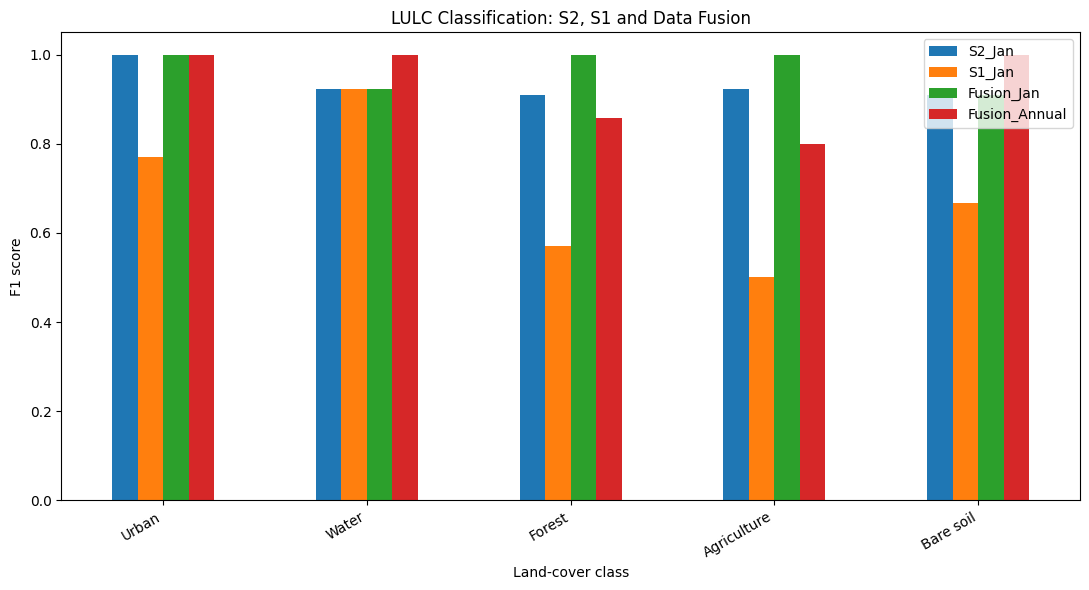

In [38]:
# Plot F1 across all four models

plot_df = (
    f1_comparison
    .set_index("class_name")[
        [
            "S2_Jan",
            "S1_Jan",
            "Fusion_Jan",
            "Fusion_Annual",
        ]
    ]
)

ax = plot_df.plot(
    kind="bar",
    figsize=(11, 6),
)

ax.set_title(
    "LULC Classification: S2, S1 and Data Fusion"
)

ax.set_xlabel("Land-cover class")
ax.set_ylabel("F1 score")
ax.set_ylim(0, 1.05)

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# Part 13 — How to interpret sensor complementarity

อย่าถามเพียงว่า

> Model ไหน OA สูงที่สุด?

ให้ถามเป็นลำดับ

### A vs B

$$
S2\quad vs\quad S1
$$

class ใดตอบสนองต่อ spectral information หรือ radar backscatter ดีกว่า?

### A vs C

$$
S2
\rightarrow
S2+S1_{Jan}
$$

same-period SAR เพิ่ม information ที่ S2 ไม่มีหรือไม่?

### C vs D

$$
S2+S1_{Jan}
\rightarrow
S2+S1_{Annual}
$$

temporal SAR ช่วย class ใด?

### สำคัญ

ถ้า Fusion ดีขึ้นเฉพาะ Agriculture แต่ไม่ช่วย Water:

> นั่นยังถือว่า fusion มีประโยชน์ เพราะ sensor complementarity ไม่จำเป็นต้องเท่ากันทุก class

# Part 14 — Variable importance by sensor source

Notebook 04 ดู importance รายเดือนแล้ว

Notebook 05 จะถามในระดับที่ใหญ่ขึ้น:

> Fusion model ใช้ข้อมูลจาก sensor ใดมากกว่า?

สำหรับ Model D:

$$
I_{S2}
=
\sum I_{\text{S2 predictors}}
$$

และ

$$
I_{S1}
=
\sum I_{\text{S1 predictors}}
$$

จากนั้นอาจแยก S1 เป็น

$$
I_{VV}
\quad vs\quad
I_{VH}
$$

### ระวัง

$$
Importance \neq Causation
$$

และ importance อาจถูกแบ่งระหว่าง predictors ที่ correlated กัน

In [39]:
# Extract Model D variable importance

importance_D = (
    clf_D
    .explain()
    .getInfo()
    .get(
        "importance",
        {}
    )
)

importance_df = pd.DataFrame({
    "predictor": list(importance_D.keys()),
    "importance": list(importance_D.values()),
})

importance_df["normalized_importance"] = (
    importance_df["importance"]
    / importance_df["importance"].sum()
)

importance_df["source"] = np.where(
    importance_df["predictor"].str.startswith("S2_"),
    "Sentinel-2",
    "Sentinel-1",
)

def get_s1_pol(name):
    if name.startswith("S1_VV_"):
        return "VV"
    if name.startswith("S1_VH_"):
        return "VH"
    return "S2"

importance_df["group"] = (
    importance_df["predictor"]
    .apply(get_s1_pol)
)

display(
    importance_df
    .sort_values(
        "normalized_importance",
        ascending=False,
    )
    .head(15)
)

,predictor,importance,normalized_importance,source,group
29,S2_B8,22.654391,0.055713,Sentinel-2,S2
30,S2_NDBI,22.504992,0.055346,Sentinel-2,S2
24,S2_B11,21.853750,0.053744,Sentinel-2,S2
25,S2_B12,21.570654,0.053048,Sentinel-2,S2
31,S2_NDVI,21.363875,0.052539,Sentinel-2,S2
32,S2_NDWI,18.130235,0.044587,Sentinel-2,S2
26,S2_B2,17.656076,0.043421,Sentinel-2,S2
4,S1_VH_Jan,16.988751,0.041780,Sentinel-1,VH
19,S1_VV_Mar,16.580712,0.040776,Sentinel-1,VV
27,S2_B3,16.216785,0.039881,Sentinel-2,S2


,source,normalized_importance
0,Sentinel-1,0.568559
1,Sentinel-2,0.431441


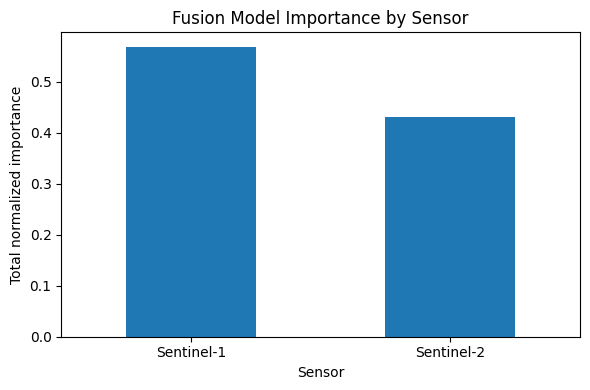

In [40]:
# Aggregate importance by sensor source

sensor_importance = (
    importance_df
    .groupby(
        "source",
        as_index=False,
    )["normalized_importance"]
    .sum()
)

display(sensor_importance)

ax = sensor_importance.plot(
    x="source",
    y="normalized_importance",
    kind="bar",
    figsize=(6, 4),
    legend=False,
)

ax.set_title(
    "Fusion Model Importance by Sensor"
)

ax.set_xlabel("Sensor")
ax.set_ylabel("Total normalized importance")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [41]:
# Aggregate into S2 / S1-VV / S1-VH

group_importance = (
    importance_df
    .groupby(
        "group",
        as_index=False,
    )["normalized_importance"]
    .sum()
    .rename(
        columns={"group": "feature_group"}
    )
)

display(group_importance)

,feature_group,normalized_importance
0,S2,0.431441
1,VH,0.288377
2,VV,0.280182


# Part 15 — Spatial disagreement

Accuracy ใช้ reference samples

แต่เรายังสามารถถามเชิง spatial ได้ว่า

> S2 และ Fusion ให้ class เหมือนกันที่ไหน และต่างกันที่ไหน?

กำหนด

$$
D(x)
=
\begin{cases}
0,& C_{S2}(x)=C_{Fusion}(x)\\
1,& C_{S2}(x)\ne C_{Fusion}(x)
\end{cases}
$$

### สำคัญ

$$
\text{Disagreement} \ne \text{Error}
$$

ถ้า model สองตัวไม่ตรงกัน  
ยังไม่สามารถบอกได้ว่าใครผิดโดยไม่มี reference information

In [42]:
# Disagreement: S2 vs Annual Fusion

disagreement = (
    class_A
    .neq(class_D)
    .rename("disagreement")
)

Map = folium.Map(
    location=[16.82, 100.27],
    zoom_start=10,
    tiles=None,
)

add_esri_imagery(Map, shown=False)

add_ee_layer(
    Map,
    class_A,
    class_vis,
    "S2 Classification",
    shown=False,
)

add_ee_layer(
    Map,
    class_D,
    class_vis,
    "S2 + Annual S1 Fusion",
    shown=True,
)

add_ee_layer(
    Map,
    disagreement.selfMask(),
    {
        "min": 1,
        "max": 1,
        "palette": ["FF00FF"],
    },
    "S2 vs Fusion disagreement",
    shown=False,
)

folium.LayerControl(
    collapsed=False
).add_to(Map)

Map

In [43]:
# Percentage of mapping area where S2 and Fusion disagree

disagree_stats = disagreement.reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=map_area,
    scale=10,
    maxPixels=1e13,
)

disagree_fraction = (
    disagree_stats
    .get("disagreement")
    .getInfo()
)

if disagree_fraction is not None:
    print(
        "S2 vs Fusion disagreement:",
        round(
            disagree_fraction * 100,
            2,
        ),
        "%",
    )
else:
    print("Could not calculate disagreement fraction.")

S2 vs Fusion disagreement: 21.8 %


# Part 16 — Final scientific interpretation

ตอบคำถามจากผลจริง

### Sensor performance

1. S2 หรือ S1 January ให้ OA สูงกว่า?
2. Water ต้องการ fusion หรือไม่?
3. Urban–Forest confusion ลดลงเมื่อเพิ่ม S2 หรือไม่?
4. Agriculture ได้ประโยชน์จาก annual SAR หรือไม่?
5. Bare soil ดีขึ้นเพราะ sensor fusion หรือ temporal trajectory?

### Fusion

6. Model C ดีกว่า Model A หรือไม่?
7. ถ้า OA ต่างน้อย แต่ Agriculture F1 เพิ่มมาก ควรถือว่า fusion มีประโยชน์หรือไม่?
8. Model D ใช้ Sentinel-1 หรือ Sentinel-2 importance มากกว่า?
9. VV และ VH ยังให้ complementary information หรือไม่?

### Spatial reasoning

10. บริเวณ disagreement กระจุกอยู่บริเวณใด?
11. Disagreement อยู่ใกล้ class boundaries หรือไม่?
12. Disagreement map สามารถใช้แทน validation map ได้หรือไม่?

### Methodology

13. เหตุใดจึงต้อง sample ก่อน แล้วค่อย clip final map?
14. ถ้า validation sample เหลือไม่ครบ 30 ควรทำอย่างไร?

# Part 17 — Export final Fusion map for QGIS

Final product ของ course คือ

```text
PHS_S2_S1_Annual_Fusion_RF_LULC_2021.tif
```

Class coding:

```text
0 = Urban
1 = Water
2 = Forest
3 = Agriculture
4 = Bare soil
255 = NoData
```

ใช้

```text
CRS   = EPSG:32647
Scale = 10 m
```

In [44]:
# Export final annual fusion classification

NO_DATA = 255

fusion_export = (
    class_D
    .toByte()
    .unmask(NO_DATA)
)

fusion_task = ee.batch.Export.image.toDrive(
    image=fusion_export,
    description="PHS_S2_S1_Annual_Fusion_RF_LULC_2021",
    folder="GEE_LULC",
    fileNamePrefix="PHS_S2_S1_Annual_Fusion_RF_LULC_2021",
    region=map_area,
    scale=10,
    crs="EPSG:32647",
    maxPixels=1e13,
    fileFormat="GeoTIFF",
    formatOptions={
        "cloudOptimized": True,
        "noData": NO_DATA,
    },
)

fusion_task.start()

print("Final fusion export:")
print(fusion_task.status())

Final fusion export:
{'state': 'READY', 'description': 'PHS_S2_S1_Annual_Fusion_RF_LULC_2021', 'priority': 100, 'creation_timestamp_ms': 1791278990781, 'update_timestamp_ms': 1791278990781, 'start_timestamp_ms': 0, 'task_type': 'EXPORT_IMAGE', 'id': 'V2T6TUA7WWGDFESSGZJUINAB', 'name': 'projects/teach-gee-github-lulc/operations/V2T6TUA7WWGDFESSGZJUINAB'}


In [45]:
# Optional: export all four maps for comparison

EXPORT_ALL_MODELS = False

if EXPORT_ALL_MODELS:
    export_models = {
        "PHS_S2_Jan_RF_LULC_2021": class_A,
        "PHS_S1_Jan_RF_LULC_2021": class_B,
        "PHS_S2_S1_Jan_Fusion_RF_LULC_2021": class_C,
    }

    tasks = []

    for name, image in export_models.items():
        task = ee.batch.Export.image.toDrive(
            image=(
                image
                .toByte()
                .unmask(NO_DATA)
            ),
            description=name,
            folder="GEE_LULC",
            fileNamePrefix=name,
            region=map_area,
            scale=10,
            crs="EPSG:32647",
            maxPixels=1e13,
            fileFormat="GeoTIFF",
            formatOptions={
                "cloudOptimized": True,
                "noData": NO_DATA,
            },
        )

        task.start()
        tasks.append(task)

    print("Optional comparison exports started.")
else:
    print(
        "Optional exports skipped. "
        "Set EXPORT_ALL_MODELS = True if needed."
    )

Optional exports skipped. Set EXPORT_ALL_MODELS = True if needed.


In [46]:
# Export model-performance summary and variable importance as CSV

summary_features = []

for row in model_summary.itertuples(index=False):
    summary_features.append(
        ee.Feature(
            None,
            {
                "model": str(row.Model),
                "predictors": int(row.Predictors),
                "validation_n": int(row.Validation_n),
                "overall_accuracy": float(row.Overall_Accuracy),
                "mean_f1": float(row.Mean_F1),
            },
        )
    )

summary_task = ee.batch.Export.table.toDrive(
    collection=ee.FeatureCollection(summary_features),
    description="PHS_S1_S2_Model_Comparison_2021",
    folder="GEE_LULC",
    fileNamePrefix="PHS_S1_S2_Model_Comparison_2021",
    fileFormat="CSV",
)

summary_task.start()

importance_features = []

for row in importance_df.itertuples(index=False):
    importance_features.append(
        ee.Feature(
            None,
            {
                "predictor": str(row.predictor),
                "importance": float(row.importance),
                "normalized_importance": float(row.normalized_importance),
                "source": str(row.source),
                "group": str(row.group),
            },
        )
    )

importance_task = ee.batch.Export.table.toDrive(
    collection=ee.FeatureCollection(importance_features),
    description="PHS_S2_S1_Fusion_Variable_Importance_2021",
    folder="GEE_LULC",
    fileNamePrefix="PHS_S2_S1_Fusion_Variable_Importance_2021",
    fileFormat="CSV",
)

importance_task.start()

print("Model summary export:", summary_task.status())
print("Variable importance export:", importance_task.status())

Model summary export: {'state': 'READY', 'description': 'PHS_S1_S2_Model_Comparison_2021', 'priority': 100, 'creation_timestamp_ms': 1791279054449, 'update_timestamp_ms': 1791279054449, 'start_timestamp_ms': 0, 'task_type': 'EXPORT_FEATURES', 'id': 'CMLUUDXIKQJY6XOKTNIAXIHX', 'name': 'projects/teach-gee-github-lulc/operations/CMLUUDXIKQJY6XOKTNIAXIHX'}
Variable importance export: {'state': 'READY', 'description': 'PHS_S2_S1_Fusion_Variable_Importance_2021', 'priority': 100, 'creation_timestamp_ms': 1791279054731, 'update_timestamp_ms': 1791279054731, 'start_timestamp_ms': 0, 'task_type': 'EXPORT_FEATURES', 'id': 'K6BL6SCQS3SXQMI3HKCBOZVQ', 'name': 'projects/teach-gee-github-lulc/operations/K6BL6SCQS3SXQMI3HKCBOZVQ'}


# Exercise — Which information is really needed?

จาก Model D มี 33 predictors

ลองสร้าง simplified fusion model โดยเลือก

```text
S2 9 predictors
+
S1 months with highest importance only
```

เช่น top 3 months ของ SAR

แล้วเปรียบเทียบ

| Model | Predictors | OA | Mean F1 |
|---|---:|---:|---:|
| Fusion-Jan | 11 | | |
| Fusion-Annual | 33 | | |
| Reduced Fusion | ? | | |

### คำถาม

1. Reduced model ให้ accuracy ใกล้ annual fusion หรือไม่?
2. ถ้า predictors ลดลงมากแต่ accuracy ลดน้อยมาก ควรเลือก model ไหน?
3. Accuracy เพียงอย่างเดียวเพียงพอสำหรับเลือก model หรือไม่?
4. Computational efficiency และ interpretability ควรถูกพิจารณาหรือไม่?

# Final take-home messages

## 1. Mapping area ≠ Reference-data domain

reference samples ต้องไม่ถูกตัดออกเพียงเพราะ final map มีขอบเขตเล็กกว่า

## 2. Optical and SAR measure different properties

```text
Sentinel-2
→ spectral reflectance

Sentinel-1
→ microwave backscatter
```

## 3. Fusion means combining complementary features

$$
\mathbf{x}_{fusion}
=
[
\mathbf{x}_{optical},
\mathbf{x}_{SAR}
]
$$

## 4. Temporal information helps some classes more than others

โดยเฉพาะ surfaces ที่เปลี่ยนตามเวลา เช่น Agriculture

## 5. More predictors ≠ automatically better model

ต้องตรวจด้วย independent hold-out validation

## 6. OA alone is not enough

ต้องดู

- PA
- UA
- F1
- class-specific errors
- sample size

## 7. Variable importance is explanatory, not causal

## 8. Disagreement ≠ Error

## 9. Classification workflow is a scientific experiment

```text
Observe
   ↓
Interpret
   ↓
Sample
   ↓
Classify
   ↓
Validate
   ↓
Compare
   ↓
Explain
```

# Course synthesis

หลังจบ Notebook 01–05 ผู้เรียนควรสามารถตอบได้ว่า

1. Sensor วัด physical property อะไร?
2. Reference data ถูกสร้างอย่างไร?
3. Training geometry มีผลอย่างไร?
4. Predictor variables คืออะไร?
5. Random Forest กำลังเรียนรู้อะไร?
6. Validation set independent จาก training หรือไม่?
7. Accuracy metric แต่ละตัวหมายถึงอะไร?
8. Temporal information ช่วย class ใด?
9. Optical และ SAR complement กันอย่างไร?
10. ข้อสรุปจาก map ไปได้ไกลแค่ไหน?

> เป้าหมายของ course ไม่ใช่เพียงสร้างแผนที่ที่ “ดูดี”  
> แต่สร้าง workflow ที่ **อธิบายได้ ตรวจสอบได้ และวิจารณ์ได้**

# References and documentation

- Google Earth Engine — Sentinel-2 SR Harmonized  
  https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S2_SR_HARMONIZED

- Google Earth Engine — Sentinel-1 GRD  
  https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S1_GRD

- Google Earth Engine — Sentinel-1 Algorithms  
  https://developers.google.com/earth-engine/guides/sentinel1

- Google Earth Engine — Random Forest  
  https://developers.google.com/earth-engine/apidocs/ee-classifier-smilerandomforest

- Google Earth Engine — sampleRegions  
  https://developers.google.com/earth-engine/apidocs/ee-image-sampleregions

- Google Earth Engine — Error Matrix  
  https://developers.google.com/earth-engine/apidocs/ee-featurecollection-errormatrix

- Google Earth Engine — Export Image to Drive  
  https://developers.google.com/earth-engine/apidocs/export-image-todrive